# K-Means. Ejercicios básicos

El algoritmo K-Means representa cada cluster por su centroide correspondiente. El algoritmo partirá el dataset en k clusters disjuntos realizando iterativamente dos operaciones:
- Calcula K clusters asignando a cada dato al cluster de su centroide más cercano
- Recalcula los centroides a partir del nuevo cluster formado

Vamos a comenzar con un ejercicio propuesto en  el libro "Python Data Science Handbook". 
Hay una implementación de K-Means en la librería Scikit-Learn  sklearn.cluster.KMeans


In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np

Vamos a empezar con un dataset 2D donde los clusters son muy evidentes. Usaremos el método *'make_blobs'* para hacer grupos separados de datos

(300, 2)


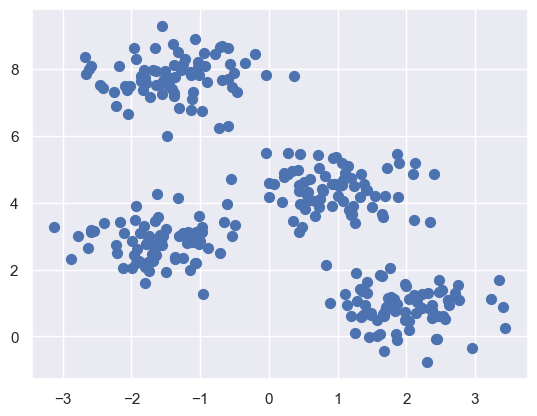

In [34]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
print(X.shape)
plt.scatter(X[:, 0], X[:, 1], s=50);
plt.show()

Vamos a usar K-Means, poniendo K=4 ya que es evidente a partir de la visualización de los datos.

In [21]:
from sklearn.cluster import KMeans
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Volvemos a dibujar los datos pero ahora asignando un color distinto a cada etiqueta proporcionada por el método KMeans

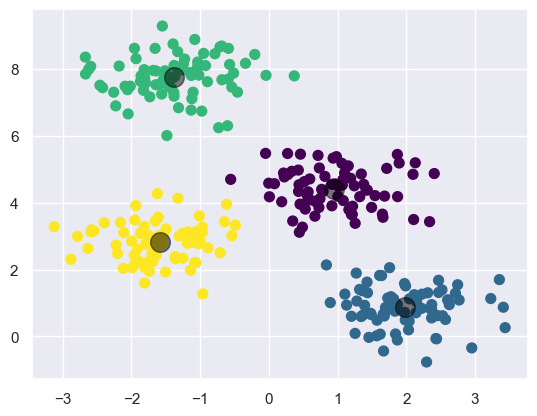

In [33]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
plt.show()

Fíjate como los centroides se sitúan en la parte central de cada cluster. Al ser de tipo Hard-Cluster, cada dato solo puede pertenecer a un cluster.
**'Escribe cuál es la configuración por defecto que ha tomado KMeans (número de iteraciones, método de inicialización (inin, n_init), criterio de parada'**. 
**'Prueba otras configuraciones de inicio, otro número de iteraciones**' y observa los resultados.
**'Prueba a cambiar el número de clusters K a valores menores y mayores que 4**' . Explica los resultados.

# K-Means: Problemas con las distribución de los datos

Como se ha indicado, KMeans asume que los clusters son compactos y pueden ser encerrados en hiperesferas. Cuando esto no se cumple, la estructura encontrada por el algoritmo no es satisfactoria.
Podemos ver un ejemplo en esta distribución en forma de lunas de dos clusters

C:\Users\victo\AppData\Local\Temp\ipykernel_21312\1588167755.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1],


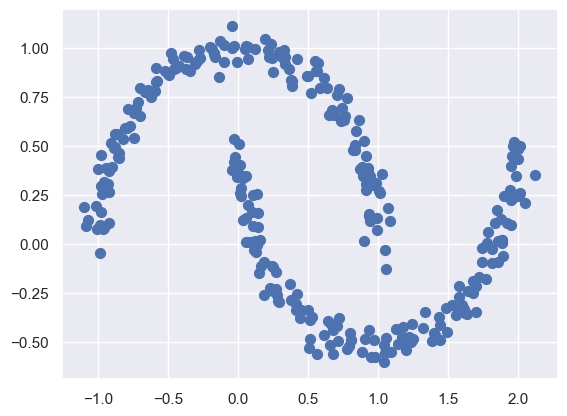

In [35]:
from sklearn.datasets import make_moons, make_circles
X, y = make_moons(300, noise=.05, random_state=0)

plt.scatter(X[:, 0], X[:, 1],
            s=50, cmap='viridis');
plt.show()

Apliquemos ahora KMeans a este conjunto de datos imponiendo K=2 correspondientes a las dos medias lunas que observamos en el mapa.

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


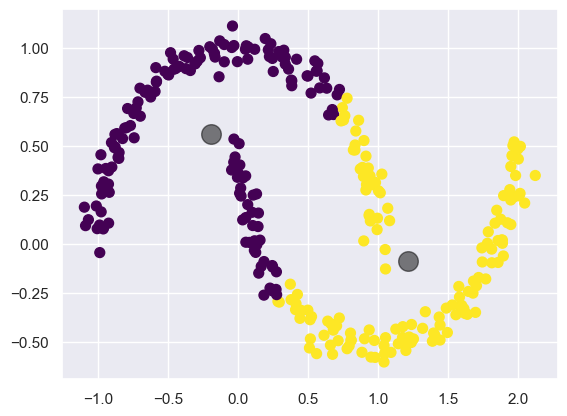

In [36]:
kmeans =  KMeans(n_clusters=2)
labels =kmeans.fit_predict(X)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');
plt.show()

**'Pregunta:**' Imagina ahora que, en este mismo Dataset, añadimos 10 ó 15 puntos alrededor de la coordenada 
    (2.0,1.0). ¿Qué ocurriría ahora en relación con la posición de los centroides? ¿Afectaría a los 
    dos centroides?

Afectaria sobre todo al centroide de la derecha, que se desplazaria hacia arriba de forma considerable, pero tambien afectaria al de la izquierda, aunque en mucha menor medida.

Veamos otro ejemplo de este mismo problema con otra configuración

C:\Users\victo\AppData\Local\Temp\ipykernel_21312\988740448.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(noisy_circles[:, 0], noisy_circles[:, 1],


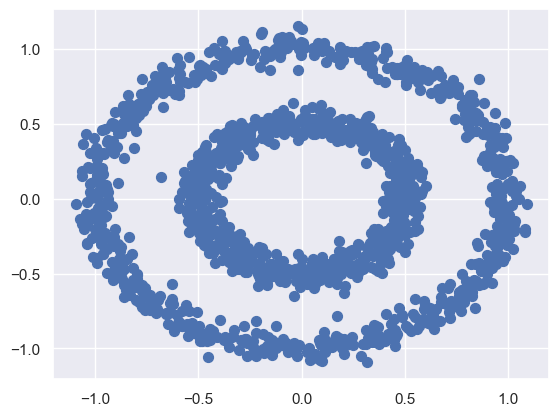

In [37]:
n_samples = 1500
noisy_circles, y_noisy = make_circles(n_samples=n_samples, factor=.5,noise=.05)

plt.scatter(noisy_circles[:, 0], noisy_circles[:, 1],
            s=50, cmap='viridis');
plt.show()

Realicemos ahora KMeans con 2 clusters y visualicemos

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


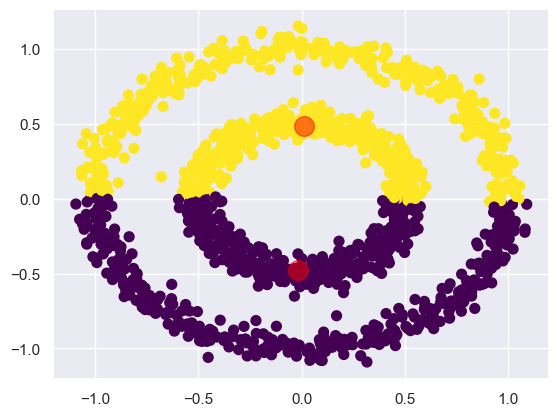

In [44]:
kmeans =  KMeans(n_clusters=2)
labels =kmeans.fit_predict(noisy_circles)
centers = kmeans.cluster_centers_

plt.scatter(noisy_circles[:, 0], noisy_circles[:, 1], c=labels,
            s=50, cmap='viridis');

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5);
plt.show()

**'Pregunta:**' Sabiendo cuál es el método de inicialización por defecto de K-Means en la librería 
de python y los rangos de valores en las dimensiones de los puntos del dataset, 
¿podrían formarse también en otras ejecuciones clusters que partieran los anillos de arriba a abajo?

Si, ya que elige dos puntos aleatorios, por lo que se podria dar el caso en el que cayeran los dos puntos arriba y abajo

Otro problema aparece cuando los clusters que pretendemos encontrar tienen varianzas en sus datos significativamente distintas

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


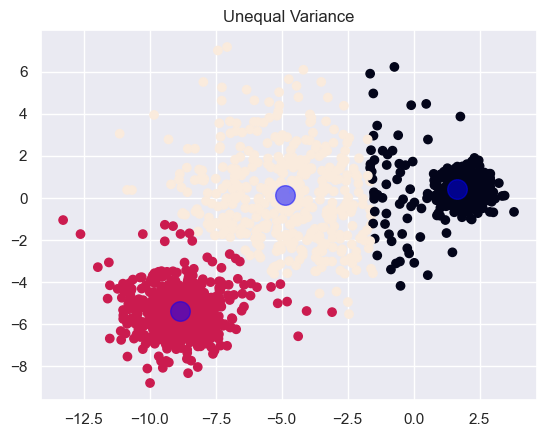

In [45]:
# Different variance
n_samples = 1500
random_state = 170
kmeans = KMeans(n_clusters=3, random_state=random_state)
X_varied, y_varied = make_blobs(n_samples=n_samples,
                                cluster_std=[1.0, 2.5, 0.5],
                                random_state=random_state)
y_pred = kmeans.fit_predict(X_varied)
centers = kmeans.cluster_centers_

plt.subplot(111)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
plt.scatter(centers[:, 0], centers[:, 1], c='blue', s=200, alpha=0.5);
plt.title("Unequal Variance")
plt.show()

**'Pregunta:**' Explica el resultado. Si usáramos la inercia de los clusters como indicador de calidad
¿Qué conclusión sacarías?

Cuanto menor es la inercia, mejor está el clustering, porque significa que los puntos están más cerca de sus centroides y, por lo tanto, los grupos son más compactos. Sin embargo, como la inercia siempre disminuye al aumentar el número de clusters k, no basta con buscar el valor mínimo.
Deberiamos escoger el valor de K en el que la inercia todavía es razonablemente baja pero que no obligue a crear demasiados clusters innecesarios. Es decir que elegiríamos el K en la zona del codo donde la inercia comienza a reducirse mas lentamente.